In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np

import geodesiq as gq

In [3]:
def H_fun(eps, DeltaL, DeltaR, tc, phiL, phiR):
    tee = tc / 2 * (1 + np.exp(1j * (phiL - phiR)))
    tgg = tc / 2 * (1 + np.exp(-1j * (phiL - phiR)))

    teg = tc / 2 * (np.exp(1j * phiL) * np.exp(1j * phiR))
    tge = -tc / 2 * (np.exp(-1j * phiL) * np.exp(-1j * phiR))

    return np.array([[eps + np.abs(DeltaL), 0, tee, teg], [0, eps - np.abs(DeltaL), tge, tgg],
                     [tee.conjugate(), tge.conjugate(), -eps + np.abs(DeltaR), 0],
                     [teg.conjugate(), tgg.conjugate(), 0, -eps - np.abs(DeltaR)]])


def H_partial(eps, DeltaL, DeltaR, tc, phiL, phiR):
    return np.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]])


DeltaL = 1
tc = 0.5 * DeltaL
DeltaR = 5 * DeltaL
phiL = 0.1
phiR = np.pi / 2
eps_min = -10 * DeltaL
eps_max = 10 * DeltaL

# Adiabatic

In [6]:
alpha = 4
beta = 2

initial_state = 1

hamiltonian = gq.Hamiltonian(H_fun, partial_H_func=H_partial)
hamiltonian.set_parameters(DeltaL=DeltaL, DeltaR=DeltaR, phiL=phiL, phiR=phiR, tc=tc)
hamiltonian.set_control(control_name='eps', pulse_initial=eps_min, pulse_final=eps_max, initial_state=initial_state,
                        alpha=alpha, beta=beta)

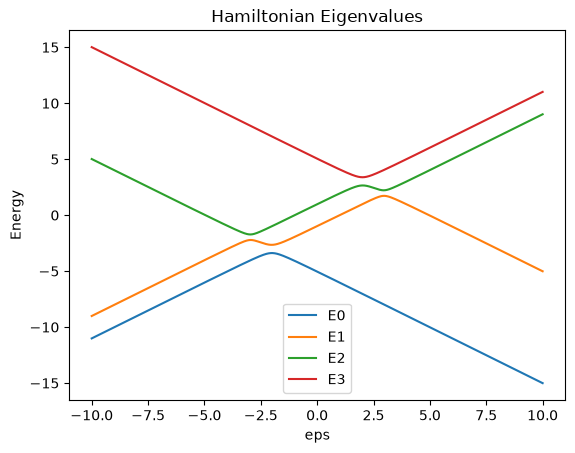

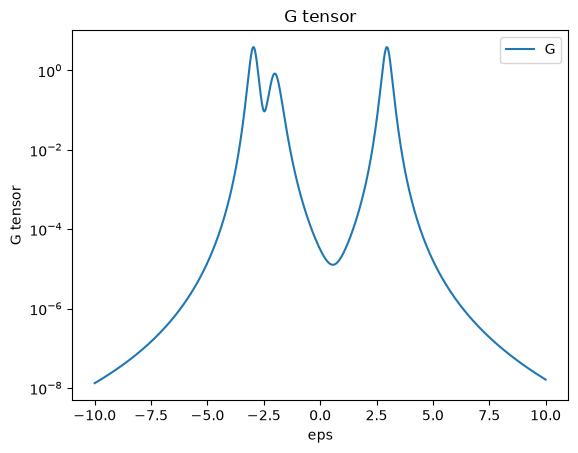

In [10]:
hamiltonian.plot_eigenvalues()
fig, ax = hamiltonian.plot_metric_tensor()
ax.set_yscale('log')

# Diabatic

In [15]:
alpha = 4
beta = 2
dia_alpha = -2.5
dia_beta = 3

initial_state = 0
final_state = 1

hamiltonian = gq.Hamiltonian(H_fun, partial_H_func=H_partial)
hamiltonian.set_parameters(DeltaL=DeltaL, DeltaR=DeltaR, phiL=phiL, phiR=phiR, tc=tc)
hamiltonian.set_control(control_name='eps', pulse_initial=eps_min, pulse_final=eps_max, initial_state=initial_state,
                        final_state=final_state, alpha=alpha, beta=beta, dia_alpha=dia_alpha, dia_beta=dia_beta)

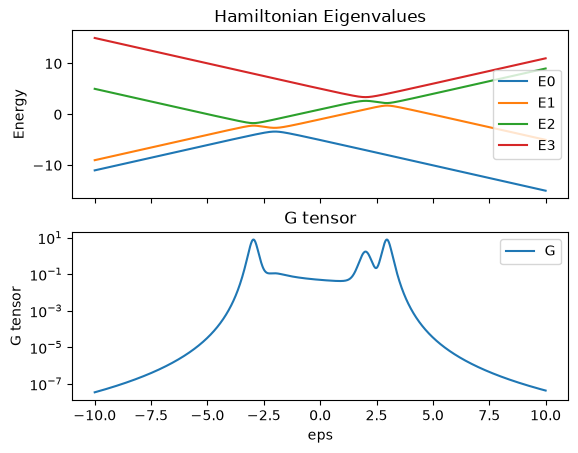

In [22]:
fig, axs = plt.subplots(2, sharex=True)

hamiltonian.plot_eigenvalues(ax=axs[0], xlabel='')
hamiltonian.plot_metric_tensor(ax=axs[1])
axs[1].set_yscale('log')

In [12]:
gq.about()


geodesiq: geometric optimal control
Authors:            Christian Ventura Meinersen & David Fernandez Fernandez
geodesiq Version:   0.1.0
Numpy Version:      2.4.6
Scipy Version:      1.17.1
QuTiP Version:      5.3.0
Matplotlib Version: 3.11.0
Python Version:     3.13.12
Number of CPUs:     24
Platform Info:      Linux (x86_64)
Installation path:  /mnt/c/Users/vawi76si/OneDrive-UniA/Projects/geodesiq-control/src/geodesiq

